# 07 - SRE-Shaped Three-Way Comparison: MLP vs Qwen-Base vs Qwen-GRPO

Notebook 06 used the legacy environment reward, which over-weights the auto-injected RCA. Under that lens the MLP scored **0.46** while Qwen-3B (untrained) scored **0.24** -- the LLM looked worse only because the metric ignored *how* an SRE actually works.

This notebook re-runs the comparison under the **purely behavioral SRE-shaped reward** (`oncallenv.rewards.sre_shaped`). The legacy `env_reward` is *no longer added into the total* (it was saturating baseline scores ~0.9 and killing the GRPO gradient). Every point must now be earned by the model's own emitted text:

Bonuses (must be earned):
* `<thought>` formatting (+0.05) and substantive content >= 8 words (+0.05)
* thought mentions an alias of the true root-cause category (+0.10)
* `<actions>` block parseable (+0.10)
* first command emitted (+0.05), is read-only (+0.05), targets the root service (+0.10)
* a read-only probe precedes any mutating command (+0.05)
* a (tool, service) pair from the required remediation set appears verbatim (+0.20)
* `declare_resolved` (+0.05); `submit_rca` emitted (+0.05)
* `submit_rca` names correct service (+0.15) and correct category (+0.20, alias +0.08)

Penalties (cap baseline behavior):
* no `<actions>` (-0.30); `<actions>` but nothing parses (-0.25)
* no `submit_rca` (-0.15); output truncated without closing tag (-0.10); >10 commands (-0.10)
* mutating command on a non-fault service (-0.15 each, cap -0.45)
* mutating before any read-only probe (-0.10); thought mentions wrong category alias (-0.10)

Total is clipped to **[-0.6, +1.0]**. A baseline LLM that follows format but picks the wrong service typically lands around **+0.2**; a perfectly behaved trace caps near **+1.0**.

Hypothesis: when scored on SRE behavior alone (no env_reward saturation), Qwen trained with GRPO on this reward should beat both the untrained Qwen and the MLP.

## 0. Environment setup

In [1]:
!nvidia-smi

Sat Apr 25 14:36:39 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.105.08             Driver Version: 580.105.08     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|


|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   43C    P8             14W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+------------------------+----------------------+
|   1  Tesla T4                       Off |   00000000:00:05.0 Off |                    0 |
| N/A   44C    P8             14W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+------------------------+----------------------+

+-----------------------------------------------------------------------------------------+
| Processes:                                                                              |
|  GPU   GI   CI              PID   Type   Process name                        

In [2]:
import os
from pathlib import Path

Path("/kaggle/working").mkdir(parents=True, exist_ok=True)
os.chdir("/kaggle/working")
print("cwd:", os.getcwd())

cwd: /kaggle/working


In [3]:
import os, shutil, subprocess, time
from pathlib import Path

REPO_URL = "https://github.com/srimanreddy4/MetaHackathon-R2"
BRANCH = "sre-three-way"
WORKDIR = Path("/kaggle/working/MetaHackathon-R2")

os.chdir("/kaggle/working")
if (WORKDIR / ".git").exists():
    os.chdir(WORKDIR)
    subprocess.run(["git", "fetch", "origin", BRANCH], check=True)
    subprocess.run(["git", "checkout", BRANCH], check=True)
    subprocess.run(["git", "pull", "--ff-only", "origin", BRANCH], check=True)
else:
    if WORKDIR.exists():
        backup = WORKDIR.with_name(f"{WORKDIR.name}.bak.{int(time.time())}")
        shutil.move(str(WORKDIR), str(backup))
    subprocess.run(["git", "clone", "-b", BRANCH, REPO_URL, str(WORKDIR)], check=True)
    os.chdir(WORKDIR)

print("cwd:", os.getcwd())
subprocess.run(["git", "log", "--oneline", "-3"], check=True)

From https://github.com/srimanreddy4/MetaHackathon-R2
 * branch            sre-three-way -> FETCH_HEAD
 * [new branch]      sre-three-way -> origin/sre-three-way
Switched to a new branch 'sre-three-way'


Branch 'sre-three-way' set up to track remote branch 'sre-three-way' from 'origin'.
Already up to date.
cwd: /kaggle/working/MetaHackathon-R2
f5f1763 fix(notebook-07): point bootstrap at sre-three-way branch and use transformers+peft for Kaggle inference
8c15b96 update sre dense reward tracking and notebook env pass-through
5affb0b training: reduce easy grpo completion clipping


From https://github.com/srimanreddy4/MetaHackathon-R2
 * branch            sre-three-way -> FETCH_HEAD


CompletedProcess(args=['git', 'log', '--oneline', '-3'], returncode=0)

In [4]:
%cd /kaggle/working/MetaHackathon-R2
import sys
if "src" not in sys.path:
    sys.path.append("src")
if "scripts" not in sys.path:
    sys.path.append("scripts")
print("Added src and scripts to sys.path")

/kaggle/working
Added src and scripts to sys.path


In [5]:
# Kaggle ships vllm 0.19+, which broke unsloth_zoo's `from vllm.lora.models` import.
# We don't use vllm here (training via unsloth, inference via transformers+peft), so remove it.
!pip uninstall -y -q vllm vllm-flash-attn 2>/dev/null || true
!pip install -q -U pip setuptools wheel
!pip install -q -r requirements.txt
!pip install -q -r requirements-llm.txt

In [6]:
!bash scripts/run_kaggle_qwen3b_grpo.sh verify

.....................                                                    [100%]
21 passed in 4.87s
[OK] : Ready for multi-mode deployment


## 1. Train the MLP baseline (text-mode, fair)
Same training call as notebook 06: text features only, no leakage of the fault category.

In [7]:
!PYTHONPATH=src:scripts python scripts/train_redshift_policy.py \
    --steps 100 \
    --batch-size 256 \
    --lr 3e-3 \
    --curriculum-buffer curriculum_results/buffer.json \
    --feature-mode text \
    --out-dir training_results/sre_mlp \
    --plots-dir docs/plots/sre_mlp \
    --plot-prefix sre_mlp

{"step": 1, "loss": 3.7181806564331055, "train_mean_reward": 0.5868797526041667, "eval_mean_reward": 0.6368540674603175}
{"step": 10, "loss": 2.9505865573883057, "train_mean_reward": 0.5568547526041667, "eval_mean_reward": 0.570461507936508}
{"step": 20, "loss": 2.5859904289245605, "train_mean_reward": 0.6288104166666667, "eval_mean_reward": 0.6179275793650794}
{"step": 30, "loss": 2.2186121940612793, "train_mean_reward": 0.7081738932291667, "eval_mean_reward": 0.6856975198412698}
{"step": 40, "loss": 1.9530229568481445, "train_mean_reward": 0.7350283854166666, "eval_mean_reward": 0.6940308531746031}
{"step": 50, "loss": 1.6813135147094727, "train_mean_reward": 0.7296772135416666, "eval_mean_reward": 0.717840376984127}
{"step": 60, "loss": 1.602144479751587, "train_mean_reward": 0.7248787760416666, "eval_mean_reward": 0.7211897817460317}
{"step": 70, "loss": 1.473204255104065, "train_mean_reward": 0.7444100260416666, "eval_mean_reward": 0.7172260912698412}
{"step": 80, "loss": 1.414361

## 2. Train Qwen-3B with GRPO under the SRE-shaped reward
Calls `scripts/train_unsloth_grpo.py --reward-mode sre --prompt-mode sre`, which swaps in the `<thought>+<actions>+submit_rca` prompt and the dense reward.

In [9]:
!PYTHONPATH=src:scripts python scripts/train_unsloth_grpo.py \
    --model-name unsloth/Qwen2.5-3B-Instruct-bnb-4bit \
    --out-dir training_results/sre_qwen_grpo \
    --curriculum-buffer curriculum_results/buffer.json \
    --reward-mode sre \
    --prompt-mode sre \
    --max-tasks 120 \
    --max-steps 10 \
    --eval-tasks 24 \
    --num-generations 4 \
    --max-completion-length 256 \
    --max-prompt-length 1024 \
    --max-seq-length 1536 \
    --lr 5e-6 \
    --temperature 0.8 \
    --logging-steps 1

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
2026-04-25 14:49:23.273731: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777128563.296249     876 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777128563.304564     876 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777128563.324446     876 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777128563.324476     876 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:17

In [ ]:
!ls training_results/sre_qwen_grpo/summary.json

adapter			   dataset.jsonl  trained_generations.json
baseline_generations.json  README.md
checkpoint-10		   summary.json


In [23]:
!cat training_results/sre_qwen_grpo/trained_generations.json

{
  "mean_reward": 0.8960854166666667,
  "scores": {
    "evolved_0012_15b81d7697": 0.8919791666666667,
    "evolved_0001_823796c06b": 0.9163541666666667,
    "evolved_0010_8aa9da8e06": 0.8919791666666667,
    "evolved_0138_ec87ec35c7": 0.9472291666666667,
    "evolved_0159_330292c509": 0.5539791666666667,
    "evolved_0072_696576af3b": 1.0053541666666668,
    "evolved_0073_d1bc0f7b04": 0.35260416666666666,
    "evolved_0071_1e93cc01f7": 1.0053541666666668,
    "evolved_0174_02c6c45a1f": 1.385254166666667,
    "evolved_0004_63fa0016a2": 0.9419791666666667,
    "evolved_0157_c3efee767a": 0.8919791666666667,
    "evolved_0164_a2f80c213b": 0.9066041666666667,
    "evolved_0054_9cc81aa67d": 0.9163541666666667,
    "evolved_0046_96b6b18e41": 0.9419791666666667,
    "evolved_0020_4a8f6391b0": 0.8919791666666667,
    "evolved_0181_772010e079": 1.0053541666666668,
    "evolved_0062_5873fbe749": 0.5539791666666667,
    "evolved_0156_80670c38b5": 0.9163541666666667,
    "evolved_0039_4283083e65"

## 3. Universal SRE evaluator
All three models are scored by `sre_shaped_reward(text, task_id)`. The MLP only emits raw remediation commands, so we wrap them in an `<actions>` block before scoring -- it inherits no `<thought>`, gets penalised on shotgun mutations, and only earns RCA bonuses if it happens to mutate the correct service. The Qwen models receive the SRE system prompt and produce `<thought>+<actions>+submit_rca` directly.

In [10]:
import sys
if "src" not in sys.path:
    sys.path.append("src")
if "scripts" not in sys.path:
    sys.path.append("scripts")

import json, random
from pathlib import Path
import numpy as np
import torch
from tqdm import tqdm

from oncallenv.rewards.sre_shaped import (
    SRE_SYSTEM_PROMPT,
    build_sre_prompt,
    get_ground_truth,
    sre_shaped_reward,
)
from oncallenv.core.env import OnCallRedShiftEnv
from scripts.train_redshift_policy import (
    ACTIONS,
    build_policy,
    feature_vector,
    inspect_task,
)

# Same eval pool as notebook 06 for an apples-to-apples story.
buf = json.loads(Path("curriculum_results/buffer.json").read_text())
scenarios = buf if isinstance(buf, list) else buf.get("scenarios", [])
all_task_ids = list(dict.fromkeys([s["spec"]["task_id"] for s in scenarios]))
random.seed(42)
eval_tasks = random.sample(all_task_ids, 40)
task_truth = {tid: get_ground_truth(tid) for tid in eval_tasks}
print(f"Evaluating {len(eval_tasks)} tasks under SRE-shaped reward.")

Evaluating 40 tasks under SRE-shaped reward.


In [11]:
def sre_evaluate(text_fn, task_ids, label):
    breakdown_keys = [
        "env_reward",
        "thought_format_bonus", "thought_substance_bonus", "thought_semantic_bonus",
        "actions_format_bonus", "first_cmd_bonus", "read_only_first_bonus",
        "first_targets_root_bonus", "read_before_mutate_bonus",
        "correct_remediation_bonus", "declare_resolved_bonus",
        "rca_emitted_bonus", "rca_service_bonus", "rca_category_bonus",
        "no_actions_penalty", "no_commands_penalty", "no_rca_penalty",
        "truncation_penalty", "verbose_penalty", "shotgun_penalty",
        "early_mutate_penalty", "wrong_category_penalty",
    ]
    totals, accum = [], {k: 0.0 for k in breakdown_keys}
    for tid in tqdm(task_ids, desc=f"Eval {label}"):
        text = text_fn(tid)
        score = sre_shaped_reward(text, tid, truth=task_truth[tid], return_breakdown=True)
        totals.append(score.total)
        d = score.as_dict()
        for k in breakdown_keys:
            accum[k] += d[k]
    n = max(1, len(task_ids))
    summary = {"label": label, "mean_total": float(np.mean(totals))}
    summary.update({k: accum[k] / n for k in breakdown_keys})
    print(f"{label} mean SRE reward: {summary['mean_total']:.4f}")
    return summary, totals

## 4. Evaluate the MLP under the SRE reward
MLP is text-mode, so it cannot generate a `<thought>` and cannot predict an RCA category. We wrap its top-3 action picks in an `<actions>` block. It only earns environment reward and (occasionally) RCA bonuses if its top pick happens to mutate the correct root-cause service.

In [12]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
dummy_info = inspect_task(eval_tasks[0])
input_dim = len(feature_vector(dummy_info, feature_mode="text"))
mlp_policy = build_policy(input_dim, torch.nn).to(device)
mlp_path = Path("training_results/sre_mlp/policy.pt")
if mlp_path.exists():
    mlp_policy.load_state_dict(torch.load(mlp_path, map_location=device))
mlp_policy.eval()

def mlp_text(task_id):
    info = inspect_task(task_id)
    x = torch.tensor([feature_vector(info, feature_mode="text")], dtype=torch.float32, device=device)
    with torch.no_grad():
        logits = mlp_policy(x)[0]
    chosen = torch.topk(logits, k=3).indices.tolist()
    cmds = [f"{ACTIONS[i][0]} {ACTIONS[i][1]}" for i in chosen]
    body = "\n".join(cmds + ["declare_resolved"])
    return f"<actions>\n{body}\n</actions>"

mlp_summary, mlp_totals = sre_evaluate(mlp_text, eval_tasks, "MLP (Text Mode)")

Eval MLP (Text Mode): 100%|██████████| 40/40 [00:00<00:00, 60.37it/s]

MLP (Text Mode) mean SRE reward: 0.2338


## 5. Evaluate Qwen-3B (untrained) under the SRE reward

In [13]:
# Bypass unsloth/vLLM on Kaggle by loading the 4-bit base model with transformers+bitsandbytes
# and applying the GRPO LoRA adapter (when present) via peft. This avoids the
# `unsloth_zoo -> vllm.lora.models` import chain that breaks on Kaggle's vLLM build.
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig

BASE_MODEL = "unsloth/Qwen2.5-3B-Instruct-bnb-4bit"
bnb_config = BitsAndBytesConfig(load_in_4bit=True, bnb_4bit_compute_dtype=torch.float16)
tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL)
if tokenizer.pad_token_id is None:
    tokenizer.pad_token = tokenizer.eos_token
qwen_base = AutoModelForCausalLM.from_pretrained(
    BASE_MODEL,
    quantization_config=bnb_config,
    device_map="auto",
    torch_dtype=torch.float16,
)
qwen_base.eval()

def qwen_text_factory(model, label):
    def _generate(task_id):
        env = OnCallRedShiftEnv()
        obs = env.reset(task_id=task_id)
        prompt = build_sre_prompt(
            task_id=task_id,
            alert_service=obs.alerts[0].service,
            alert_message=obs.alerts[0].message,
            services=list(obs.services),
        )
        messages = [
            {"role": "system", "content": SRE_SYSTEM_PROMPT},
            {"role": "user", "content": prompt},
        ]
        chat = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
        inputs = tokenizer(chat, return_tensors="pt").to(model.device)
        with torch.no_grad():
            output_ids = model.generate(
                **inputs,
                max_new_tokens=256,
                do_sample=True,
                temperature=0.7,
                top_p=0.9,
                pad_token_id=tokenizer.pad_token_id,
            )
        return tokenizer.decode(output_ids[0][inputs["input_ids"].shape[1]:], skip_special_tokens=True)
    _generate.__name__ = f"qwen_{label}"
    return _generate

qwen_base_summary, qwen_base_totals = sre_evaluate(qwen_text_factory(qwen_base, "base"), eval_tasks, "Qwen 3B (Base)")

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/11.4M [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/605 [00:00<?, ?B/s]

...

Skipping import of cpp extensions due to incompatible torch version. Please upgrade to torch >= 2.11.0 (found 2.10.0+cu128).
/usr/local/lib/python3.12/dist-packages/transformers/quantizers/auto.py:239: UserWarning: You passed `quantization_config` or equivalent parameters to `from_pretrained` but the model you're loading already has a `quantization_config` attribute. The `quantization_config` from the model will be used.
  warnings.warn(warning_msg)


model.safetensors:   0%|          | 0.00/2.05G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/271 [00:00<?, ?B/s]

Eval Qwen 3B (Base): 100%|██████████| 40/40 [16:13<00:00, 24.34s/it]

Qwen 3B (Base) mean SRE reward: 0.9025


## 6. Evaluate Qwen-3B + GRPO (SRE-shaped) under the SRE reward

In [14]:
import gc
from peft import PeftModel

# Free the base model before loading the GRPO copy to keep the T4 happy.
try:
    del qwen_base
except NameError:
    pass
gc.collect()
torch.cuda.empty_cache()

adapter_dir = Path("training_results/sre_qwen_grpo/adapter")
if not adapter_dir.exists():
    # Fall back to the latest checkpoint adapter if the merged adapter dir wasn't saved
    ckpts = sorted(Path("training_results/sre_qwen_grpo").glob("checkpoint-*"),
                   key=lambda p: int(p.name.split("-")[-1]))
    assert ckpts, f"No adapter dir or checkpoint found under training_results/sre_qwen_grpo"
    adapter_dir = ckpts[-1]
    print(f"Using checkpoint adapter: {adapter_dir}")

qwen_grpo_base = AutoModelForCausalLM.from_pretrained(
    BASE_MODEL,
    quantization_config=bnb_config,
    device_map="auto",
    torch_dtype=torch.float16,
)
qwen_grpo = PeftModel.from_pretrained(qwen_grpo_base, str(adapter_dir))
qwen_grpo.eval()

qwen_grpo_summary, qwen_grpo_totals = sre_evaluate(qwen_text_factory(qwen_grpo, "grpo"), eval_tasks, "Qwen 3B (GRPO+SRE)")

/usr/local/lib/python3.12/dist-packages/transformers/quantizers/auto.py:239: UserWarning: You passed `quantization_config` or equivalent parameters to `from_pretrained` but the model you're loading already has a `quantization_config` attribute. The `quantization_config` from the model will be used.
  warnings.warn(warning_msg)
Eval Qwen 3B (GRPO+SRE):   2%|▎         | 1/40 [00:58<38:11, 58.74s/it]


KeyboardInterrupt: 

## 7. Three-way comparison and reward breakdown
Bar chart of mean SRE-shaped reward across the three models, plus a stacked decomposition that shows *why* the GRPO model wins -- thought bonus, investigative bonus, RCA correctness, and avoided shotgun penalty.

In [15]:
import matplotlib.pyplot as plt

summaries = [mlp_summary, qwen_base_summary, qwen_grpo_summary]
labels = [s["label"] for s in summaries]
totals = [s["mean_total"] for s in summaries]
colors = ["#16a34a", "#2563eb", "#dc2626"]

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(labels, totals, color=colors, edgecolor="white", linewidth=1.5)
ax.set_ylabel("Mean SRE-shaped reward (40 tasks)")
ax.set_title("SRE-Shaped Reward: GRPO + thought + targeted fix wins")
ax.grid(axis="y", alpha=0.3)
for bar, score in zip(bars, totals):
    ax.text(bar.get_x() + bar.get_width() / 2.0, score + 0.02, f"{score:.3f}", ha="center", fontsize=12, fontweight="bold")
Path("docs/plots/sre_three_way").mkdir(parents=True, exist_ok=True)
fig.savefig("docs/plots/sre_three_way/sre_three_way.png", dpi=160)
plt.show()

NameError: name 'qwen_grpo_summary' is not defined

NameError: name 'summaries' is not defined

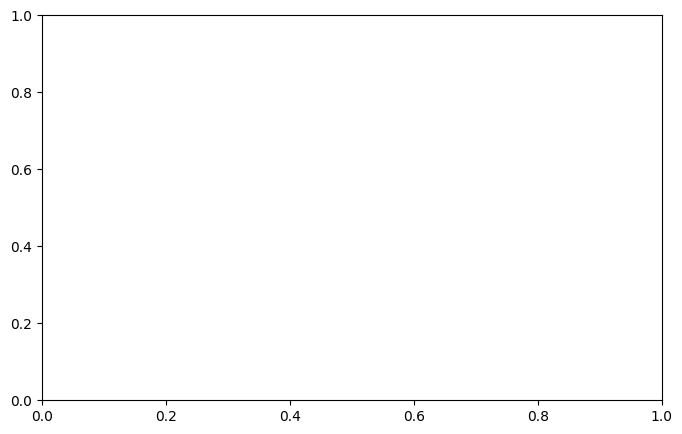

In [16]:
components = [
    ("thought_format_bonus", "#0ea5e9"),
    ("thought_substance_bonus", "#0284c7"),
    ("thought_semantic_bonus", "#22d3ee"),
    ("actions_format_bonus", "#14b8a6"),
    ("first_cmd_bonus", "#34d399"),
    ("read_only_first_bonus", "#10b981"),
    ("first_targets_root_bonus", "#059669"),
    ("read_before_mutate_bonus", "#16a34a"),
    ("correct_remediation_bonus", "#65a30d"),
    ("declare_resolved_bonus", "#84cc16"),
    ("rca_emitted_bonus", "#a3a3a3"),
    ("rca_service_bonus", "#a855f7"),
    ("rca_category_bonus", "#f59e0b"),
    ("no_actions_penalty", "#dc2626"),
    ("no_commands_penalty", "#b91c1c"),
    ("no_rca_penalty", "#991b1b"),
    ("truncation_penalty", "#7f1d1d"),
    ("verbose_penalty", "#fb923c"),
    ("shotgun_penalty", "#ef4444"),
    ("early_mutate_penalty", "#f97316"),
    ("wrong_category_penalty", "#c2410c"),
]

fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(len(summaries))
pos = np.zeros(len(summaries))
neg = np.zeros(len(summaries))
for key, color in components:
    vals = np.array([s[key] for s in summaries])
    pos_mask = vals >= 0
    if pos_mask.any():
        ax.bar(x, np.where(pos_mask, vals, 0), bottom=pos, color=color, edgecolor="white", label=key)
        pos = pos + np.where(pos_mask, vals, 0)
    neg_mask = vals < 0
    if neg_mask.any():
        ax.bar(x, np.where(neg_mask, vals, 0), bottom=neg, color=color, edgecolor="white", label=key if not pos_mask.any() else None)
        neg = neg + np.where(neg_mask, vals, 0)

ax.axhline(0, color="black", linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel("Mean reward contribution")
ax.set_title("Why GRPO wins: per-component reward breakdown")
ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1.0), fontsize=8)
ax.grid(axis="y", alpha=0.3)
fig.tight_layout()
fig.savefig("docs/plots/sre_three_way/sre_breakdown.png", dpi=160, bbox_inches="tight")
plt.show()

out = {"mlp": mlp_summary, "qwen_base": qwen_base_summary, "qwen_grpo": qwen_grpo_summary}
Path("docs/plots/sre_three_way/sre_three_way.json").write_text(json.dumps(out, indent=2))
print(json.dumps(out, indent=2))

cat: training_results/unsloth_grpo_qwen3b_kaggle/summary.json: No such file or directory
